Packages

In [1]:
import xarray as xr
import pandas as pd
import geopandas as gpd
from xoak import SklearnGeoBallTreeAdapter
from arraylake import Client
import icechunk as ic
import time

In [2]:
from arraylake import Client
client = Client()
client.login()

Successfully refreshed tokens! Token stored at /home/jovyan/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: eli.holmes@noaa.gov                                                                                      │
│ Id: 2dc9d4d8-2f0f-42a5-bc88-f0ab2126efb9                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

The primary function: resamples the selected model configuration to match the survey footprint, and adds the data as a new column to a copy of the survey file

In [4]:
def resamplemodel(label, fsurvey, fout):

    if label == "romsb10k_TDS_CORECFS_temp_bottom5m":
        yr = range(1970,2024,5)
        vname = "temp_bottom5m"
        fdata = [f"https://data.pmel.noaa.gov/aclim/thredds/dodsC/B10K-K20_CORECFS/Level2/{yyyy}-{yyyy+4}/B10K-K20_CORECFS_{yyyy}-{yyyy+4}_average_{vname}.nc" for yyyy in yr]

        ds = xr.open_mfdataset(fdata, data_vars='all')
        
        ds_coord = xr.open_dataset("https://data.pmel.noaa.gov/aclim/thredds/dodsC/ancillary/Bering10K_extended_grid.nc")
        ds['mask'] = ds_coord['mask_rho'] == 1
        ds_coord.close()

        ltname = "lat_rho"
        lnname = "lon_rho"
        tname = "ocean_time"
        vname = "temp"
        
        zname=""

    elif label == "mom6nep_TDS_r20250912_tob":

        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")
        ds_data = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/daily/raw/r20250912/tob.nep.full.hcast.daily.raw.r20250912.199301-202506.nc")

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])
        ds['mask'] = ds['wet'] == 1

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"
        vname = "tob"

        zname = ""

        ds_coord.close()
        ds_data.close()

    elif label == "mom6nep_TDS_r20250912_nh4_bottom":

        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")
        ds_data = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/nh4.nep.full.hcast.monthly.raw.r20250912.199301-202506.nc")

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])
        ds['mask'] = ds['wet'] == 1

        # ds = ds.dropna(dim="z_l").isel(z_l=-1)

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"
        vname = "nh4"

        zname = "z_l"
        zsel = -1

        ds_coord.close()
        ds_data.close()

    elif label == "mom6nep_EM_r20250912_tob":
        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")

        client = Client()
        repo = client.get_repo("NOAA-PMEL/cefi-nep-hindcast-daily")
        session = repo.readonly_session(branch="main")
        ds_data = xr.open_zarr(session.store, zarr_format=3, group="raw/main", decode_timedelta=True)

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])
        ds['mask'] = ds['wet'] == 1

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"
        vname = "tob"

        zname = ""

        ds_coord.close()
        ds_data.close()

    elif label == "mom6nep_EM_r20250912_nh4_bottom":
        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")

        client = Client()
        repo = client.get_repo("NOAA-PMEL/cefi-nep-hindcast-monthly")
        session = repo.readonly_session(branch="main")
        ds_data = xr.open_zarr(session.store, zarr_format=3, group="raw/main", decode_timedelta=True)
        vname = "nh4"
        ds_data = ds_data[vname] # we don't need all of them...

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])

        ds['mask'] = ds['wet'] == 1

        # ds = ds.dropna(dim="z_l").isel(z_l=-1)

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"

        zname = "z_l"
        zsel = -1

        ds_coord.close()
        ds_data.close()

    elif label == "mom6nep_SC_r20250912_tob":
        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")

        url = "https://data.source.coop/eeholmes/cefi/nepacific-icechunk"
        storage = ic.http_storage(url)
        containers = ic.Repository.open(storage).config.virtual_chunk_containers or []
        store = ic.Repository.open(
            storage,
            authorize_virtual_chunk_access={prefix: None for prefix in containers},
        ).readonly_session("main").store

        ds_data = xr.open_zarr(store, consolidated=False, group="daily/raw/aux")

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])
        ds['mask'] = ds['wet'] == 1

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"
        vname = "tob"

        zname = ""

        ds_coord.close()
        ds_data.close()

    elif label == "mom6nep_SC_r20250912_nh4_bottom":
        ds_coord = xr.open_dataset("http://psl.noaa.gov/thredds/dodsC/Projects/CEFI/regional_mom6/cefi_portal/northeast_pacific/full_domain/hindcast/monthly/raw/r20250912/ocean_static.nc")

        url = "https://data.source.coop/eeholmes/cefi/nepacific-icechunk"
        storage = ic.http_storage(url)
        containers = ic.Repository.open(storage).config.virtual_chunk_containers or []
        store = ic.Repository.open(
            storage,
            authorize_virtual_chunk_access={prefix: None for prefix in containers},
        ).readonly_session("main").store

        ds_data = xr.open_zarr(store, consolidated=False, group="monthly/raw/main")

        vname = "nh4"
        ds_data = ds_data[vname] # we don't need all of them...

        ds_coord = ds_coord.set_coords(['geolon','geolat'])
        ds = xr.merge([ds_coord, ds_data])

        ds['mask'] = ds['wet'] == 1

        # ds = ds.dropna(dim="z_l").isel(z_l=-1)

        ltname = "geolat"
        lnname = "geolon"
        tname = "time"

        zname = "z_l"
        zsel = -1

        ds_coord.close()
        ds_data.close()
        
    svy = pd.read_csv(fsurvey)

    ds_svy = xr.Dataset.from_dataframe(svy)

    # Mask out land

    ds[ltname] = ds[ltname].where(ds.mask)
    ds[lnname] = ds[lnname].where(ds.mask)

    ds[ltname] = ds[ltname].fillna(0) # works since 0,0 is far from region, but not universal
    ds[lnname] = ds[lnname].fillna(0)

    # Create index using haversine distance
    # Note: I'd rather be able to do this in projected coordinates, but I haven't figured out how to adapt the NDPointIndex for that

    ds = ds.set_xindex(
        (ltname, lnname), 
        xr.indexes.NDPointIndex, 
        tree_adapter_cls=SklearnGeoBallTreeAdapter)

    dimsel = {ltname: ds_svy['latitude'], 
              lnname: ds_svy['longitude'],
               tname: ds_svy['start_time'],
            'method': 'nearest'}
    ds_nearest = ds.sel(**dimsel)

    if zname:
        if (zsel==-1):
            ds_nearest[vname] = ds_nearest[vname].dropna(**{'dim': zname}).isel(**{zname: -1})
        # TODO: need to add logic for vertical sel/isel selection when not bottom

    svy[label] = ds_nearest[vname].values

    ds.close()

    svy.to_csv(fout, index=False)

Time test for all current options

In [6]:
label = "romsb10k_TDS_CORECFS_temp_bottom5m"
fsurvey = 'https://raw.githubusercontent.com/afsc-gap-products/coldpool/main/data/index_hauls_temperature_data.csv'
fout = "surveyrep_time_test.csv"

# We'll use a few years worth of the survey as our test

svy = pd.read_csv(fsurvey)
svy = svy[svy['start_time'].between('2021-01-01','2025-01-01')]
svy.to_csv(fout)

# Model configurations

modelconfig = ["romsb10k_TDS_CORECFS_temp_bottom5m",
               "mom6nep_TDS_r20250912_tob",
               "mom6nep_TDS_r20250912_nh4_bottom",
               "mom6nep_EM_r20250912_tob",
               "mom6nep_EM_r20250912_nh4_bottom"]

modelconfig = ["mom6nep_EM_r20250912_tob",
               "mom6nep_EM_r20250912_nh4_bottom"]

modelconfig = ["mom6nep_SC_r20250912_tob",
              "mom6nep_EM_r20250912_tob",
              "mom6nep_EM_r20250912_nh4_bottom",
              "mom6nep_SC_r20250912_nh4_bottom"]

# Time it

for mlabel in modelconfig:

    ts = time.perf_counter()
    try:
        resamplemodel(label=mlabel, fsurvey=fout, fout=fout)
        te = time.perf_counter()
        etime = te - ts
        print(f"{mlabel:35s}: {etime:.6f} seconds")
    except Exception as err:
        te = time.perf_counter()
        etime = te - ts
        print(f"{mlabel:35s}: {etime:.6f} seconds (FAILED: {err})")
        


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


mom6nep_SC_r20250912_tob           : 4.436007 seconds


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


mom6nep_EM_r20250912_tob           : 4.576527 seconds


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


mom6nep_EM_r20250912_nh4_bottom    : 16.053134 seconds


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/tmp/ipykernel_1312/2336342727.py:149: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_data = xr.open_zarr(store, consolidated=False, group="monthly/raw/main")


mom6nep_SC_r20250912_nh4_bottom    : 17.149698 seconds


In [21]:
from arraylake import Client
client = Client()
client.login()

import xarray as xr
client = Client()
repo = client.get_repo("NOAA-PMEL/cefi-nep-hindcast-monthly")
session = repo.readonly_session(branch="main")
ds_em_main = xr.open_zarr(session.store, zarr_format=3, group="raw/main")
ds_em_aux1 = xr.open_zarr(session.store, zarr_format=3, group="raw/aux1")

Successfully refreshed tokens! Token stored at /home/jovyan/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: eli.holmes@noaa.gov                                                                                      │
│ Id: 2dc9d4d8-2f0f-42a5-bc88-f0ab2126efb9                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/tmp/ipykernel_271/2920354150.py:9: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_em_main = xr.open_zarr(session.store, zarr_format=3, group="raw/main")
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codec

In [5]:
ds_em_main.volcello

<xarray.DataArray 'volcello' (time: 390, z_l: 52, jh: 816, ih: 342)> Size: 23GB
dask.array<open_dataset-volcello, shape=(390, 52, 816, 342), dtype=float32, chunksize=(100, 10, 200, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-16T12:00:00 ... 2025-06-16
  * z_l      (z_l) float64 416B 2.5 7.5 12.5 17.5 ... 5.25e+03 5.75e+03 6.25e+03
  * jh       (jh) float64 7kB 0.5 1.5 2.5 3.5 4.5 ... 812.5 813.5 814.5 815.5
  * ih       (ih) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 338.5 339.5 340.5 341.5
Attributes:
    units:          m3
    long_name:      Ocean grid-cell volume
    cell_methods:   area:sum z_l:sum jh:sum ih:sum time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_volume

In [20]:
import icechunk as ic
url = "https://data.source.coop/eeholmes/cefi/nepacific-icechunk"
storage = ic.http_storage(url)
containers = ic.Repository.open(storage).config.virtual_chunk_containers or []
store = ic.Repository.open(
    storage,
    authorize_virtual_chunk_access={prefix: None for prefix in containers},
).readonly_session("main").store

ds_sc_main = xr.open_zarr(store, consolidated=False, group="monthly/raw/main")
ds_sc_aux1 = xr.open_zarr(store, consolidated=False, group="monthly/raw/aux1")


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/tmp/ipykernel_271/1370558216.py:10: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_sc_main = xr.open_zarr(store, consolidated=False, group="monthly/raw/main")
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr

In [22]:
vars1 = set(ds_em_main.data_vars)
vars2 = set(ds_sc_main.data_vars)

only_in_ds1 = sorted(vars1 - vars2)
only_in_ds2 = sorted(vars2 - vars1)
in_both = sorted(vars1 & vars2)

print("Only in main EM:")
print(only_in_ds1)

print("\nOnly in main SC:")
print(only_in_ds2)

Only in main EM:
[]

Only in main SC:
['co3os', 'no3']


In [23]:
vars1 = set(ds_em_aux1.data_vars)
vars2 = set(ds_sc_aux1.data_vars)

only_in_ds1 = sorted(vars1 - vars2)
only_in_ds2 = sorted(vars2 - vars1)
in_both = sorted(vars1 & vars2)

print("Only in aux1 EM:")
print(only_in_ds1)

print("\nOnly in aux1 SC:")
print(only_in_ds2)

Only in aux1 EM:
['volcello']

Only in aux1 SC:
[]


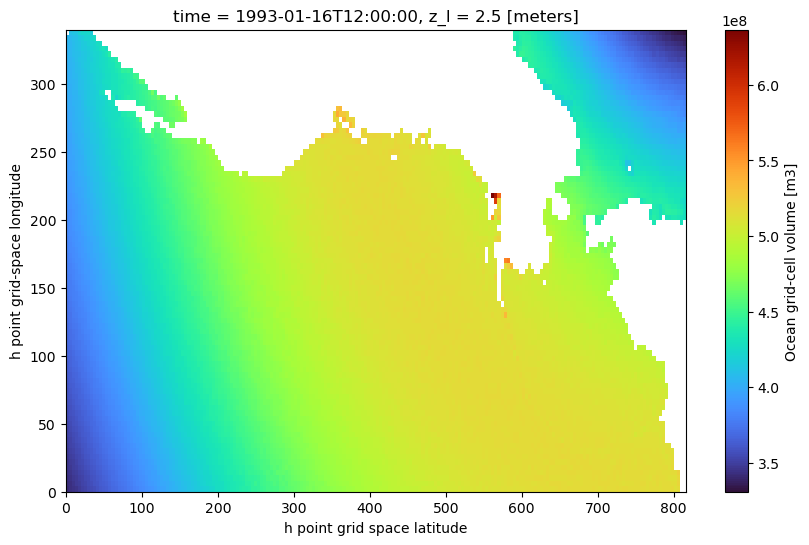

In [19]:
da = ds_em_main.volcello.isel(time=0, z_l=0)

da_coarse = da.coarsen(
    jh=4,
    ih=4,
    boundary="trim",
).mean()

da_coarse.plot(
    x="jh",
    y="ih",
    figsize=(10, 6),
    cmap="turbo",
)

In [16]:
ds_em_main.volcello

<xarray.DataArray 'volcello' (time: 390, z_l: 52, jh: 816, ih: 342)> Size: 23GB
dask.array<open_dataset-volcello, shape=(390, 52, 816, 342), dtype=float32, chunksize=(100, 10, 200, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-16T12:00:00 ... 2025-06-16
  * z_l      (z_l) float64 416B 2.5 7.5 12.5 17.5 ... 5.25e+03 5.75e+03 6.25e+03
  * jh       (jh) float64 7kB 0.5 1.5 2.5 3.5 4.5 ... 812.5 813.5 814.5 815.5
  * ih       (ih) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 338.5 339.5 340.5 341.5
Attributes:
    units:          m3
    long_name:      Ocean grid-cell volume
    cell_methods:   area:sum z_l:sum jh:sum ih:sum time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  ocean_volume